# Trabajo final: análisis y clasificación de acciones de Microsoft
## Avance de las sesiones 01 y 02: Pandas, NumPy, Scikit-learn y PyTorch

**Problema:** una empresa de análisis financiero necesita un procedimiento reproducible para preparar archivos de mercado, interpretar sus datos y evaluar predicciones. Microsoft es la empresa cuyas acciones se estudian; no es la empresa que solicita la solución.

**Objetivo:** evaluar si apertura, máximo, mínimo, cierre y volumen de una sesión ayudan a clasificar si el cierre de la siguiente sesión subirá o no. La predicción se plantea **después del cierre actual**.

**Utilidad esperada:** entregar datos revisados, gráficos y resultados comparables para que un analista valore la utilidad de los modelos. No se presupone una mejora predictiva ni rentabilidad.

**Este avance incorpora:** validación cronológica, estandarización de las cinco entradas para una red pequeña en PyTorch, tensores, entrenamiento con gradientes y comparación con Random Forest y una referencia sencilla.

**Pendientes del caso completo:** NLP con reportes reales, SciPy/NLTK, una red temporal con TensorFlow/Keras y el informe técnico final. La red densa de este avance utiliza una sesión por ejemplo: no es una LSTM ni utiliza secuencias de varias sesiones.


## Antes de ejecutar
1. Coloca este notebook junto a `MSFT(1).csv` o `MSFT.csv`. También admite la estructura `notebooks/` y `data/` del proyecto anterior.
2. Selecciona el kernel de tu entorno virtual en VS Code.
3. Instala las librerías en ese entorno si faltan:

```bash
python -m pip install numpy pandas matplotlib seaborn scikit-learn ipykernel
python -m pip install torch --index-url https://download.pytorch.org/whl/cpu
```

La red es pequeña y trabaja en CPU: no necesita una tarjeta gráfica. No se instalan paquetes automáticamente desde las celdas. Si tu versión de Python no tiene una distribución compatible de PyTorch, consulta el selector oficial: https://pytorch.org/get-started/locally/

4. Reinicia el kernel y ejecuta todas las celdas en orden. Las cifras y conclusiones se generan a partir de esa ejecución.

**Fuente del CSV:** https://www.kaggle.com/datasets/varpit94/microsoft-stock-data

**Material:** Sesión 01 (Pandas, NumPy, matrices y preparación; pp. 55, 60, 69, 74 y 84) y Sesión 02 (X/y, clasificación, partición, Scikit-learn, evaluación, redes, tensores y entrenamiento; pp. 23–39 y 41–58).


## 1. Herramientas
Pandas organiza las tablas; NumPy opera sobre vectores y matrices; Matplotlib y Seaborn presentan resultados. Scikit-learn entrenará y evaluará el clasificador.


In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Pandas:",
    pd.__version__,
    "| NumPy:",
    np.__version__,
    "| Scikit-learn:",
    sklearn.__version__)


Pandas: 3.0.5 | NumPy: 2.5.2 | Scikit-learn: 1.9.0


## 2. Carga y significado del dataset
Cada fila corresponde a una sesión bursátil de Microsoft. Los datos son precios históricos de la acción, no ventas de productos ni ganancias de Microsoft. Las series históricas pueden estar ajustadas por el proveedor; no deben interpretarse automáticamente como cotizaciones nominales originales de décadas pasadas.

| Columna original | Nombre utilizado | Significado |
|---|---|---|
| Date | Fecha | Sesión de negociación |
| Open | Apertura | Precio de apertura registrado |
| High | Maximo | Máximo de la sesión |
| Low | Minimo | Mínimo de la sesión |
| Close | Cierre | Precio de cierre registrado |
| Adj Close | Cierre_Ajustado | Cierre con ajustes del proveedor; se conserva fuera del modelo inicial |
| Volume | Volumen | Volumen de acciones negociadas reportado por la fuente |

**Utilidad:** conocer qué representa cada observación antes de efectuar cálculos.


In [15]:
# Busca el CSV junto al notebook o en las carpetas data del proyecto.
candidatas = [carpeta / nombre
              for carpeta in [Path("."), Path("data"), Path("../data")]
              for nombre in ["MSFT(1).csv", "MSFT.csv"]]

# Elige la primera ruta existente; si no encuentra el CSV, devuelve None.
ruta_archivo = next((ruta for ruta in candidatas if ruta.is_file()), None)

# Detiene la ejecución si esta comprobación detecta un problema.
if ruta_archivo is None:
    raise FileNotFoundError("Coloca MSFT(1).csv o MSFT.csv junto al notebook o en data/.")

# Lee el archivo y conserva esta tabla como referencia original.
df_original = pd.read_csv(ruta_archivo)

print("Archivo:", ruta_archivo.name)
print("Dimensiones:", df_original.shape)
print(df_original.head().to_string(index=False))

df_original.info()


Archivo: MSFT.csv
Dimensiones: (9083, 7)
      Date     Open     High      Low    Close  Adj Close     Volume
1986-03-13 0.088542 0.101563 0.088542 0.097222   0.061434 1031788800
1986-03-14 0.097222 0.102431 0.097222 0.100694   0.063628  308160000
1986-03-17 0.100694 0.103299 0.100694 0.102431   0.064725  133171200
1986-03-18 0.102431 0.103299 0.098958 0.099826   0.063079   67766400
1986-03-19 0.099826 0.100694 0.097222 0.098090   0.061982   47894400
<class 'pandas.DataFrame'>
RangeIndex: 9083 entries, 0 to 9082
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9083 non-null   str    
 1   Open       9083 non-null   float64
 2   High       9083 non-null   float64
 3   Low        9083 non-null   float64
 4   Close      9083 non-null   float64
 5   Adj Close  9083 non-null   float64
 6   Volume     9083 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 496.9 KB


## 3. Comprobación y preparación
**Utilidad:** detectar problemas que podrían alterar el análisis. Que no existan nulos o duplicados es un resultado válido; no se fabrican errores para justificar la limpieza.

Se revisan columnas esperadas, fechas, números, vacíos, duplicados y coherencia de precios. No se aplica el recorte de 1982 del S&P 500. Si aparecen problemas de precios o datos faltantes, se detiene el proceso para investigarlos: eliminarlos sin revisar podría unir sesiones no consecutivas.


In [16]:
# Relaciona los nombres originales con sus traducciones al español.
nombres = {
    "Date": "Fecha",
    "Open": "Apertura",
    "High": "Maximo",
    "Low": "Minimo",
    "Close": "Cierre",
    "Adj Close": "Cierre_Ajustado",
    "Volume": "Volumen",
}

# Comprueba que el CSV incluya todas las columnas necesarias.
faltantes = set(nombres) - set(df_original.columns)

# Detiene la ejecución si esta comprobación detecta un problema.
if faltantes:
    raise ValueError(f"Faltan columnas: {faltantes}")

# Prepara una copia de los datos para trabajar sin modificar el CSV.
df = df_original.rename(columns=nombres).copy()

print("Nulos originales por columna:")
print(df.isna().sum())

# Cuenta los registros repetidos antes de eliminarlos.
duplicados = int(df.duplicated().sum())

# Elimina solamente filas completamente repetidas.
df = df.drop_duplicates().copy()

# Convierte el texto a fechas; los valores que no se puedan convertir quedan como nulos.
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")

# Identifica las columnas que deben contener números.
numericas = ["Apertura", "Maximo", "Minimo", "Cierre", "Cierre_Ajustado", "Volumen"]

# Convierte cada columna numérica y marca como nulos los textos inválidos.
for columna in numericas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

# Detiene la ejecución si esta comprobación detecta un problema.
if df[["Fecha"] + numericas].isna().any().any():
    raise ValueError("Hay fechas o números ausentes/inválidos. Revisarlos antes de continuar.")

# Detiene la ejecución si esta comprobación detecta un problema.
if not np.isfinite(df[numericas].to_numpy()).all():
    raise ValueError("Hay valores numéricos infinitos.")

# Detiene la ejecución si esta comprobación detecta un problema.
if df["Fecha"].duplicated().any():
    raise ValueError("Hay fechas repetidas con registros distintos; revisar la fuente.")

# Ordena las sesiones de la más antigua a la más reciente.
df = df.sort_values("Fecha").reset_index(drop=True)

# Selecciona los precios que deben ser mayores que cero.
precios = ["Apertura", "Maximo", "Minimo", "Cierre", "Cierre_Ajustado"]

print("Precios no positivos:")
print((df[precios] <= 0).sum())

# Marca filas con precios imposibles o volumen negativo.
# El máximo debe ser al menos igual a apertura y cierre; el mínimo no debe superarlos.
incoherentes = ((df[precios] <= 0).any(axis=1) | (df["Volumen"] < 0)
               | (df["Maximo"] < df[["Apertura", "Cierre", "Minimo"]].max(axis=1))
               | (df["Minimo"] > df[["Apertura", "Cierre", "Maximo"]].min(axis=1)))

# Detiene la ejecución si esta comprobación detecta un problema.
if incoherentes.any():
    raise ValueError("Se detectaron precios o volúmenes incoherentes. Revisar esos registros.")

print("Duplicados completos eliminados:", duplicados)
print("Registros preparados:", len(df))
print("Periodo:", df["Fecha"].min().date(), "a", df["Fecha"].max().date())


Nulos originales por columna:
Fecha              0
Apertura           0
Maximo             0
Minimo             0
Cierre             0
Cierre_Ajustado    0
Volumen            0
dtype: int64
Precios no positivos:
Apertura           0
Maximo             0
Minimo             0
Cierre             0
Cierre_Ajustado    0
dtype: int64
Duplicados completos eliminados: 0
Registros preparados: 9083
Periodo: 1986-03-13 a 2022-03-24


## 4. Estadística y NumPy
**Utilidad:** resumir miles de sesiones y representar numéricamente la información. La media del cierre resume el período, no predice el cierre siguiente. La desviación del nivel del precio durante décadas tampoco equivale a la volatilidad de los retornos.

Las cinco columnas originales forman una matriz: una fila por sesión y una columna por característica. Más adelante se seleccionará la misma información en X, manteniendo sus nombres para facilitar la interpretación.


In [17]:
# Estas cinco columnas originales serán las entradas del modelo.
variables_independientes = ["Apertura", "Maximo", "Minimo", "Cierre", "Volumen"]

print(df[variables_independientes].describe().T.round(3).to_string())

# Convierte una columna en un vector de NumPy.
vector_cierres = df["Cierre"].to_numpy()

# Representa las sesiones como filas y las cinco características como columnas.
matriz_financiera = df[variables_independientes].to_numpy()

print("Forma del vector:", vector_cierres.shape)
print("Forma de la matriz:", matriz_financiera.shape)
print("Cierre promedio:", round(np.mean(vector_cierres), 3))
print("Cierre mínimo:", round(np.min(vector_cierres), 3))
print("Cierre máximo:", round(np.max(vector_cierres), 3))
print("Desviación de los cierres:", round(np.std(vector_cierres), 3))


           count          mean           std          min           25%          50%           75%           max
Apertura  9083.0  4.132500e+01  5.969700e+01        0.089  4.051000e+00        26.82  4.003500e+01  3.446200e+02
Maximo    9083.0  4.176100e+01  6.027200e+01        0.092  4.102000e+00        27.10  4.044400e+01  3.496700e+02
Minimo    9083.0  4.087800e+01  5.908200e+01        0.089  4.027000e+00        26.52  3.950000e+01  3.422000e+02
Cierre    9083.0  4.133600e+01  5.971500e+01        0.090  4.075000e+00        26.84  3.993800e+01  3.431100e+02
Volumen   9083.0  5.875055e+07  3.845200e+07  2304000.000  3.461230e+07  52032000.00  7.265400e+07  1.031789e+09
Forma del vector: (9083,)
Forma de la matriz: (9083, 5)
Cierre promedio: 41.336
Cierre mínimo: 0.09
Cierre máximo: 343.11
Desviación de los cierres: 59.711


## 5. Un indicador solo para analizar: retorno diario
**Utilidad:** comparar cambios relativos. Pasar de 100 a 102 equivale a 2 %, igual que pasar de 200 a 204.

`Retorno_Diario = Cierre actual / Cierre anterior - 1`. Un valor de 0,02 representa 2 %. No incluye dividendos y no es una ganancia de inversión garantizada. El primer registro queda sin retorno porque no conocemos su cierre anterior.

Este indicador **no entra en X**. Se conserva para análisis y gráficos; no se calculan medias móviles, distancias ni volatilidades para el modelo.


In [18]:
# Calcula el cambio relativo del cierre. Se utiliza en el análisis, no en X.
df["Retorno_Diario"] = df["Cierre"].pct_change(fill_method=None)

# Excluye el primer retorno vacío antes de calcular estadísticas.
vector_retornos = df["Retorno_Diario"].dropna().to_numpy()

print("Retorno diario medio:", f"{np.mean(vector_retornos):.3%}")
print("Desviación de retornos:", f"{np.std(vector_retornos):.3%}")
print("Peor variación:", f"{np.min(vector_retornos):.3%}")
print("Mayor variación:", f"{np.max(vector_retornos):.3%}")

# Agrupa las sesiones por año y resume precios, volumen y cambios diarios.
resumen_anual = df.groupby(df["Fecha"].dt.year).agg(
    Sesiones=("Cierre",
        "size"),
    Cierre_Promedio=("Cierre",
        "mean"),
    Volumen_Promedio=("Volumen",
        "mean"),
    Retorno_Diario_Medio=("Retorno_Diario",
        "mean"))

print(resumen_anual.tail(10).round(4).to_string())
print("Los años extremos pueden estar incompletos. El retorno diario medio no es el retorno anual acumulado.")


Retorno diario medio: 0.111%
Desviación de retornos: 2.133%
Peor variación: -30.116%
Mayor variación: 19.565%
       Sesiones  Cierre_Promedio  Volumen_Promedio  Retorno_Diario_Medio
Fecha                                                                   
2013        252          32.4919      4.861547e+07                0.0015
2014        252          42.4535      3.333175e+07                0.0009
2015        252          46.7143      3.595022e+07                0.0009
2016        252          55.2593      3.103066e+07                0.0006
2017        251          71.9840      2.243617e+07                0.0013
2018        251         101.0340      3.159019e+07                0.0008
2019        252         130.3820      2.458099e+07                0.0018
2020        253         193.0261      3.765959e+07                0.0017
2021        252         275.9408      2.601301e+07                0.0017
2022         57         300.0172      3.920391e+07               -0.0015
Los años extre

## 6. Visualización para el analista
La línea muestra la evolución observada, el histograma la frecuencia de los cambios y la dispersión la relación entre apertura y cierre de la **misma sesión**. Esa relación no demuestra capacidad para anticipar otra sesión. Los gráficos son descriptivos.


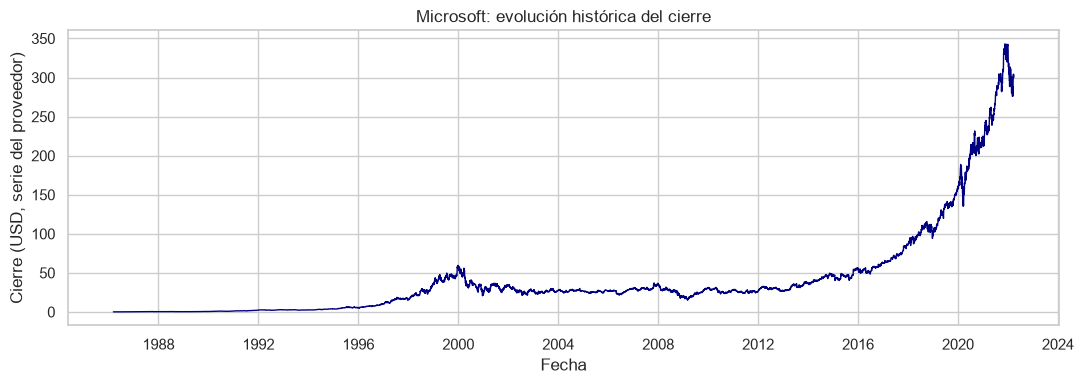

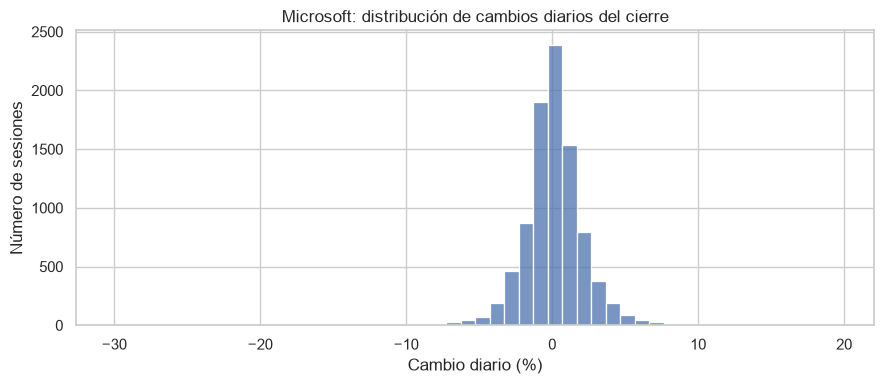

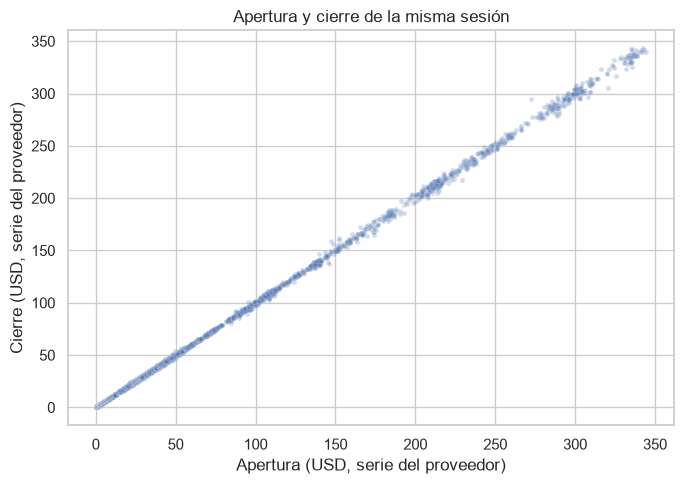

In [19]:
# Crea una figura independiente para el siguiente gráfico.
plt.figure(figsize=(11, 4))
plt.plot(df["Fecha"], df["Cierre"], color="navy", linewidth=1)
plt.title("Microsoft: evolución histórica del cierre")
plt.xlabel("Fecha")
plt.ylabel("Cierre (USD, serie del proveedor)")
plt.tight_layout()
plt.show()

# Crea una figura independiente para el siguiente gráfico.
plt.figure(figsize=(9, 4))

# Multiplica las proporciones por 100 para mostrar el eje en porcentaje.
sns.histplot(df["Retorno_Diario"].dropna() * 100, bins=50)
plt.title("Microsoft: distribución de cambios diarios del cierre")
plt.xlabel("Cambio diario (%)")
plt.ylabel("Número de sesiones")
plt.tight_layout()
plt.show()

# Crea una figura independiente para el siguiente gráfico.
plt.figure(figsize=(7, 5))

# Cada punto compara apertura y cierre de una misma sesión.
sns.scatterplot(data=df, x="Apertura", y="Cierre", alpha=0.25, s=12)
plt.title("Apertura y cierre de la misma sesión")
plt.xlabel("Apertura (USD, serie del proveedor)")
plt.ylabel("Cierre (USD, serie del proveedor)")
plt.tight_layout()
plt.show()


## 7. Definir X e y
**X:** apertura, máximo, mínimo, cierre y volumen actuales. Elegimos columnas originales para construir una primera versión fácil de interpretar. No afirmamos que sean mejores que indicadores derivados; los niveles cambian entre épocas y pueden dificultar la generalización.

**y:** 1 si el cierre de la próxima sesión es mayor; 0 si baja o se mantiene. Es clasificación binaria supervisada, no una predicción del precio exacto.

El cierre siguiente se usa solo para construir la respuesta histórica. Se elimina de las entradas para que el modelo no vea la respuesta. La fecha siguiente identifica la sesión evaluada: un viernes puede apuntar al lunes. La última fila no tiene respuesta conocida, por lo que se excluye del conjunto etiquetado.


In [20]:
# Prepara los registros destinados al aprendizaje supervisado.
df_ml = df[["Fecha"] + variables_independientes].copy()

# Desplaza la fecha siguiente hacia la fila actual para identificar la sesión objetivo.
df_ml["Fecha_Objetivo"] = df_ml["Fecha"].shift(-1)

# Consulta el cierre siguiente solo para construir la respuesta histórica.
df_ml["Cierre_Siguiente"] = df_ml["Cierre"].shift(-1)

# Excluye la última sesión porque no conocemos su respuesta futura.
df_ml = df_ml.dropna(subset=["Cierre_Siguiente", "Fecha_Objetivo"]).copy()

# Asigna 1 cuando sube y 0 cuando baja o se mantiene.
df_ml["Tendencia_Siguiente_Dia"] = (df_ml["Cierre_Siguiente"] > df_ml["Cierre"]).astype(int)

print(df_ml[["Fecha",
            "Cierre",
            "Fecha_Objetivo",
            "Cierre_Siguiente",
            "Tendencia_Siguiente_Dia"]].head(8).to_string(index=False))

# Retira el cierre futuro para impedir que llegue al modelo como pista.
df_ml = df_ml.drop(columns="Cierre_Siguiente")

# X contiene las pistas disponibles al terminar la sesión actual.
X = df_ml[variables_independientes]

# y contiene la respuesta histórica: 1 = sube, 0 = no sube.
y = df_ml["Tendencia_Siguiente_Dia"]

print("X:", X.shape, "| y:", y.shape)

# Cuenta cuántos ejemplos hay de cada clase, incluyendo posibles clases vacías.
distribucion = y.value_counts().reindex([0, 1], fill_value=0)

print(pd.DataFrame({"Cantidad": distribucion,
            "Porcentaje": distribucion / len(y) * 100}).round(2))


     Fecha   Cierre Fecha_Objetivo  Cierre_Siguiente  Tendencia_Siguiente_Dia
1986-03-13 0.097222     1986-03-14          0.100694                        1
1986-03-14 0.100694     1986-03-17          0.102431                        1
1986-03-17 0.102431     1986-03-18          0.099826                        0
1986-03-18 0.099826     1986-03-19          0.098090                        0
1986-03-19 0.098090     1986-03-20          0.095486                        0
1986-03-20 0.095486     1986-03-21          0.092882                        0
1986-03-21 0.092882     1986-03-24          0.090278                        0
1986-03-24 0.090278     1986-03-25          0.092014                        1
X: (9082, 5) | y: (9082,)
                         Cantidad  Porcentaje
Tendencia_Siguiente_Dia                      
0                            4502       49.57
1                            4580       50.43


## 8. Entrenamiento, validación y prueba en orden cronológico

| Conjunto | Proporción aproximada | Función |
|---|---|---|
| Entrenamiento | Primer 60 % | Aprender pesos o reglas |
| Validación | Siguiente 20 % | Elegir la época de la red sin usar la prueba |
| Prueba | Último 20 % | Comparar el resultado posterior de los modelos ya fijados |

**Relación con clase:** la sesión 02 explica la partición para evaluar datos nuevos. Añadimos validación para decidir cuándo detener el entrenamiento de la red. No usamos K-Fold aleatorio porque las observaciones tienen orden temporal.

Dejamos una sesión de separación en cada frontera para que las etiquetas de un conjunto no utilicen el cierre de la primera sesión del siguiente. Ambos modelos reciben exactamente las mismas filas de entrenamiento y prueba.

**Transparencia:** el último período ya fue visto en la versión anterior del notebook. Lo conservamos para comparar, pero no es una prueba completamente nueva dentro del proyecto. Una confirmación independiente necesitaría datos posteriores o un período reservado que todavía no se haya examinado. Tampoco se comparan directamente las cifras del entrenamiento 80/20 anterior con este entrenamiento 60/20/20.


In [21]:
# Calcula las posiciones que separan los tres períodos.
fin_entrenamiento = int(len(df_ml) * 0.60)
inicio_prueba = int(len(df_ml) * 0.80)

# Excluye una fila en cada frontera temporal.
datos_train = df_ml.iloc[:fin_entrenamiento - 1].copy()
datos_val = df_ml.iloc[fin_entrenamiento:inicio_prueba - 1].copy()
datos_test = df_ml.iloc[inicio_prueba:].copy()

# Selecciona las mismas cinco entradas para cada conjunto.
X_train = datos_train[variables_independientes]
X_val = datos_val[variables_independientes]
X_test = datos_test[variables_independientes]

y_train = datos_train["Tendencia_Siguiente_Dia"]
y_val = datos_val["Tendencia_Siguiente_Dia"]
y_test = datos_test["Tendencia_Siguiente_Dia"]

# Verifica que ninguna etiqueta alcance el siguiente conjunto.
assert datos_train["Fecha_Objetivo"].max() < datos_val["Fecha"].min()
assert datos_val["Fecha_Objetivo"].max() < datos_test["Fecha"].min()

# Muestra el período y las proporciones reales de las clases.
particiones = []

for nombre, datos in [
    ("Entrenamiento", datos_train),
    ("Validación", datos_val),
    ("Prueba", datos_test),
]:
    particiones.append({
        "Conjunto": nombre,
        "Sesiones": len(datos),
        "Desde": datos["Fecha"].min().date(),
        "Hasta": datos["Fecha"].max().date(),
        "Subidas (%)": datos["Tendencia_Siguiente_Dia"].mean() * 100,
    })

print(pd.DataFrame(particiones).round(2).to_string(index=False))
print("Sesiones excluidas entre conjuntos: 2")


     Conjunto  Sesiones      Desde      Hasta  Subidas (%)
Entrenamiento      5448 1986-03-13 2007-10-16        49.58
   Validación      1815 2007-10-18 2015-01-02        49.64
       Prueba      1817 2015-01-06 2022-03-23        53.77
Sesiones excluidas entre conjuntos: 2


## 9. Primer modelo: Random Forest
Conservamos la configuración inicial, sin buscar parámetros a partir del resultado de prueba. La comparación con la red utiliza las mismas cinco columnas originales.

**Para explicar:** el bosque combina árboles que aprenden reglas. La red aprenderá pesos numéricos. Que ambos se entrenen sin errores no demuestra que sus predicciones sean útiles.


In [22]:
from sklearn.ensemble import RandomForestClassifier

# Mantiene una configuración fija para este experimento.
modelo_rf = RandomForestClassifier(
    n_estimators=300,          # Número de árboles.
    max_depth=8,              # Límite de complejidad por árbol.
    min_samples_leaf=10,      # Ejemplos mínimos en cada hoja.
    class_weight="balanced", # Compensa las frecuencias de las clases.
    random_state=42,          # Semilla reproducible.
    n_jobs=-1,                # Núcleos disponibles.
)

# Aprende solo con el primer período.
modelo_rf.fit(X_train, y_train)
print("Random Forest entrenado.")


Random Forest entrenado.


## 10. Preparar las entradas para PyTorch
**¿Por qué estandarizar?** El volumen puede tener millones de unidades y los precios otra escala. La red opera con pesos y gradientes; acercar las escalas facilita su entrenamiento.

`StandardScaler` resta la media de cada columna y divide entre su desviación, calculadas **solo en entrenamiento**. La validación y la prueba se transforman con esas mismas cifras. No se usa `fit` sobre todo el CSV.

**Seguimos usando las cinco variables originales.** Estandarizarlas cambia su representación numérica, no crea indicadores financieros adicionales. No garantiza que los precios futuros queden dentro del rango histórico.

**Tensor:** una estructura numérica que PyTorch utiliza para operar y calcular gradientes. Aquí X tiene forma `(sesiones, 5)` e y tiene forma `(sesiones, 1)`.


In [23]:
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler

# Usa CPU y una semilla fija para esta pequeña demostración.
torch.manual_seed(42)
torch.set_num_threads(2)
print("Versión de PyTorch:", torch.__version__)

# Aprende la transformación exclusivamente del entrenamiento.
escalador = StandardScaler()
X_train_escalado = escalador.fit_transform(X_train)
X_val_escalado = escalador.transform(X_val)
X_test_escalado = escalador.transform(X_test)

# Convierte las matrices NumPy en tensores de 32 bits.
X_train_tensor = torch.tensor(X_train_escalado, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_escalado, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_escalado, dtype=torch.float32)

# Cada respuesta debe ocupar una fila y una columna.
y_train_tensor = torch.tensor(
    y_train.to_numpy().reshape(-1, 1),
    dtype=torch.float32,
)
y_val_tensor = torch.tensor(
    y_val.to_numpy().reshape(-1, 1),
    dtype=torch.float32,
)

print("X de entrenamiento:", tuple(X_train_tensor.shape))
print("y de entrenamiento:", tuple(y_train_tensor.shape))
print("Medias y desviaciones aprendidas del entrenamiento:")
print(pd.DataFrame({
    "Variable": variables_independientes,
    "Media": escalador.mean_,
    "Desviacion": escalador.scale_,
}).round(3).to_string(index=False))


ModuleNotFoundError: No module named 'torch'

## 11. Crear una red neuronal pequeña
La arquitectura utiliza **5 entradas → 8 neuronas ocultas → 1 salida**. Se mantiene pequeña para entenderla y poder ejecutarla en CPU.

| Componente | Función |
|---|---|
| `Linear(5, 8)` | Combina las cinco entradas mediante pesos y sesgos |
| `ReLU()` | Introduce una transformación no lineal |
| `Linear(8, 1)` | Produce un puntaje de salida llamado logit |
| `BCEWithLogitsLoss()` | Mide el error de clasificación binaria a partir de los logits |
| `Adam` | Actualiza los pesos usando los gradientes |

Durante la evaluación aplicamos `sigmoid` al logit y usamos un umbral fijo de 0,5 para asignar 0 o 1. Ese valor entre 0 y 1 es una estimación del modelo: **no afirmamos que sea una probabilidad calibrada**. La función de pérdida ya incorpora internamente la operación necesaria; no ponemos otra sigmoid antes de calcularla.

Esta red densa aplica los fundamentos de la sesión 02. No satisface por sí sola el requisito posterior de una red que procese secuencias temporales.


In [ ]:
# Crea las capas en el orden en que se procesará la información.
modelo_torch = nn.Sequential(
    nn.Linear(5, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
)

# Define cómo medir el error y cómo actualizar los pesos.
funcion_perdida = nn.BCEWithLogitsLoss()
optimizador = torch.optim.Adam(
    modelo_torch.parameters(),
    lr=0.001,
)

print(modelo_torch)
print("Parámetros entrenables:", sum(p.numel() for p in modelo_torch.parameters()))


Sequential(
  (0): Linear(in_features=5, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)
Parámetros entrenables: 57


## 12. Entrenar y observar la validación
Esta celda aplica el ciclo de la **página 58 de la sesión 02**:

1. **Forward:** calcula la salida.
2. **Loss:** mide el error frente a la respuesta histórica.
3. **Backward:** calcula cómo cambia el error respecto a cada peso.
4. **Step:** actualiza los pesos.

Una época realiza aquí una actualización usando todo el pequeño conjunto de entrenamiento. Después medimos el error de validación **sin actualizar pesos**.

Guardamos los pesos de la época con menor pérdida de validación y detenemos el proceso si pasan 30 épocas sin mejorar. El máximo es 300 épocas. Este criterio se fija antes de ver la prueba; no se modifica hasta obtener una cifra deseada.

La pérdida es una medida para entrenar: **no es un porcentaje de errores** ni una pérdida monetaria.


In [ ]:
from copy import deepcopy

# Límites de entrenamiento y memoria de la mejor época.
max_epocas = 300
paciencia = 30
sin_mejora = 0
mejor_perdida = float("inf")
mejor_epoca = 0
mejores_pesos = None
historial = []

for epoca in range(1, max_epocas + 1):
    modelo_torch.train()

    # Borra gradientes anteriores antes de calcular los nuevos.
    optimizador.zero_grad()

    # 1. Forward: calcula un logit por sesión.
    logits = modelo_torch(X_train_tensor)

    # 2. Loss: compara las salidas con las respuestas conocidas.
    perdida = funcion_perdida(logits, y_train_tensor)

    # 3. Backward: Autograd calcula los gradientes.
    perdida.backward()

    # 4. Step: Adam actualiza los pesos de la red.
    optimizador.step()

    # Evalúa ambos conjuntos después de la actualización, sin gradientes.
    modelo_torch.eval()
    with torch.no_grad():
        perdida_train = funcion_perdida(
            modelo_torch(X_train_tensor), y_train_tensor
        ).item()
        perdida_val = funcion_perdida(
            modelo_torch(X_val_tensor), y_val_tensor
        ).item()

    historial.append({
        "Epoca": epoca,
        "Entrenamiento": perdida_train,
        "Validacion": perdida_val,
    })

    # Conserva únicamente la época elegida mediante validación.
    if perdida_val < mejor_perdida:
        mejor_perdida = perdida_val
        mejor_epoca = epoca
        mejores_pesos = deepcopy(modelo_torch.state_dict())
        sin_mejora = 0
    else:
        sin_mejora += 1

    if epoca == 1 or epoca % 50 == 0:
        print(f"Época {epoca}: train={perdida_train:.4f}, val={perdida_val:.4f}")

    if sin_mejora >= paciencia:
        print("Detención por falta de mejora en validación.")
        break

# Recupera los mejores pesos; no utiliza la última época por defecto.
modelo_torch.load_state_dict(mejores_pesos)
modelo_torch.eval()

historial = pd.DataFrame(historial)
print("Épocas realizadas:", len(historial))
print("Época seleccionada:", mejor_epoca)
print("Mejor pérdida de validación:", round(mejor_perdida, 4))


Época 1: train=0.6943, val=0.6927
Detención por falta de mejora en validación.
Épocas realizadas: 32
Época seleccionada: 2
Mejor pérdida de validación: 0.6927


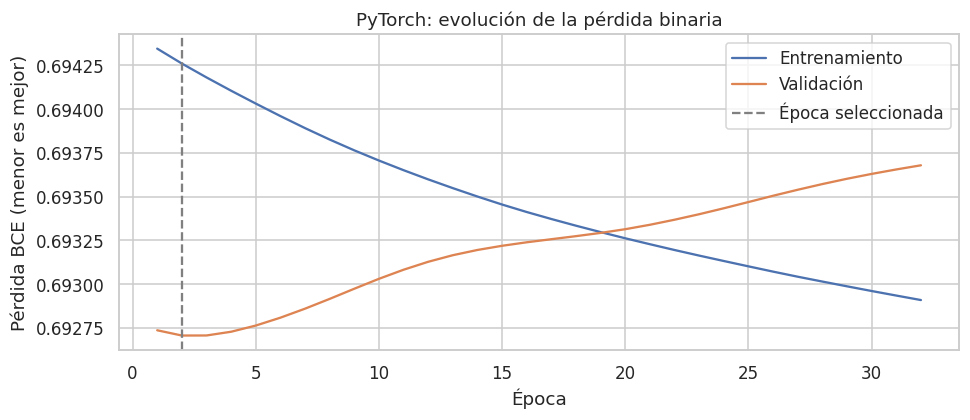

In [ ]:
# Compara cómo evolucionó el error en entrenamiento y validación.
plt.figure(figsize=(9, 4))
plt.plot(historial["Epoca"], historial["Entrenamiento"], label="Entrenamiento")
plt.plot(historial["Epoca"], historial["Validacion"], label="Validación")
plt.axvline(mejor_epoca, color="gray", linestyle="--", label="Época seleccionada")
plt.title("PyTorch: evolución de la pérdida binaria")
plt.xlabel("Época")
plt.ylabel("Pérdida BCE (menor es mejor)")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Evaluar los modelos fijados
La clase positiva es **sube (1)**. Se usa el mismo período para comparar todos los modelos.

| Métrica | Interpretación |
|---|---|
| Accuracy | Fracción total de aciertos |
| Balanced Accuracy | Promedio de la detección de ambas clases; ayuda a identificar modelos que casi siempre responden lo mismo |
| Precision de sube | Entre las subidas anunciadas, cuántas ocurrieron |
| Recall de sube | Entre las subidas reales, cuántas se detectaron |
| F1 de sube | Media armónica de Precision y Recall |

La referencia repite la clase mayoritaria **del entrenamiento**. Si nunca anuncia subidas, su Precision se muestra como 0 mediante `zero_division=0`; no significa que haya emitido alertas falsas.

Primero mostramos la validación y después la prueba. La red ya tiene sus pesos seleccionados; no se elige el umbral ni se vuelve a entrenar mirando la prueba.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Reutiliza las mismas definiciones para todos los modelos.
def metricas(real, predicha):
    return {
        "Accuracy": accuracy_score(real, predicha),
        "Balanced Accuracy": balanced_accuracy_score(real, predicha),
        "Precision": precision_score(real, predicha, zero_division=0),
        "Recall": recall_score(real, predicha, zero_division=0),
        "F1": f1_score(real, predicha, zero_division=0),
    }

# Convierte logits en clases sin modificar pesos.
def predecir_red(entradas):
    modelo_torch.eval()
    with torch.no_grad():
        estimaciones = torch.sigmoid(modelo_torch(entradas)).numpy().ravel()
    return (estimaciones >= 0.5).astype(int)

clase_mayoritaria = int(y_train.mode().iloc[0])
print("Clase fija de referencia:", clase_mayoritaria)

predicciones_val = {
    "Referencia": np.full(len(y_val), clase_mayoritaria),
    "Random Forest": modelo_rf.predict(X_val),
    "PyTorch": predecir_red(X_val_tensor),
}

resultados_val = pd.DataFrame({
    nombre: metricas(y_val, predicha)
    for nombre, predicha in predicciones_val.items()
}).T

print("VALIDACIÓN: métricas en porcentaje")
print((resultados_val * 100).round(2).to_string())


Clase fija de referencia: 0
VALIDACIÓN: métricas en porcentaje
               Accuracy  Balanced Accuracy  Precision  Recall     F1
Referencia        50.36              50.00       0.00    0.00   0.00
Random Forest     52.56              52.51      52.59   45.06  48.54
PyTorch           50.19              49.84       0.00    0.00   0.00


In [ ]:
# Evalúa el período final con los modelos ya fijados.
predicciones_test = {
    "Referencia": np.full(len(y_test), clase_mayoritaria),
    "Random Forest": modelo_rf.predict(X_test),
    "PyTorch": predecir_red(X_test_tensor),
}

resultados_test = pd.DataFrame({
    nombre: metricas(y_test, predicha)
    for nombre, predicha in predicciones_test.items()
}).T

print("PRUEBA: métricas en porcentaje")
print((resultados_test * 100).round(2).to_string())

# Contrasta entrenamiento con períodos posteriores para detectar diferencias.
predicciones_train = {
    "Random Forest": modelo_rf.predict(X_train),
    "PyTorch": predecir_red(X_train_tensor),
}

resumen_generalizacion = pd.DataFrame({
    nombre: {
        "Train": accuracy_score(y_train, predicciones_train[nombre]),
        "Validacion": resultados_val.loc[nombre, "Accuracy"],
        "Prueba": resultados_test.loc[nombre, "Accuracy"],
    }
    for nombre in predicciones_train
}).T

print("EXACTITUD POR PERÍODO (%)")
print((resumen_generalizacion * 100).round(2).to_string())


PRUEBA: métricas en porcentaje
               Accuracy  Balanced Accuracy  Precision  Recall    F1
Referencia        46.23              50.00        0.0    0.00  0.00
Random Forest     46.23              49.79       50.0    2.56  4.87
PyTorch           46.23              50.00        0.0    0.00  0.00
EXACTITUD POR PERÍODO (%)
               Train  Validacion  Prueba
Random Forest  67.57       52.56   46.23
PyTorch        49.87       50.19   46.23


## 14. Comparar aciertos, errores y tendencias
**Utilidad para el analista:** ver qué tipos de error comete cada modelo, no limitarse a un único porcentaje.

En el gráfico temporal, cada punto resume **20 sesiones consecutivas de prueba, sin superposición**. Muestra el porcentaje de subidas reales y anunciadas en ese bloque. El último bloque puede tener menos sesiones. Coincidir en la proporción de subidas no demuestra acertar las mismas sesiones: por eso también se incluyen las matrices de confusión.

Este gráfico compara direcciones; no presenta un precio futuro que el modelo nunca calculó.


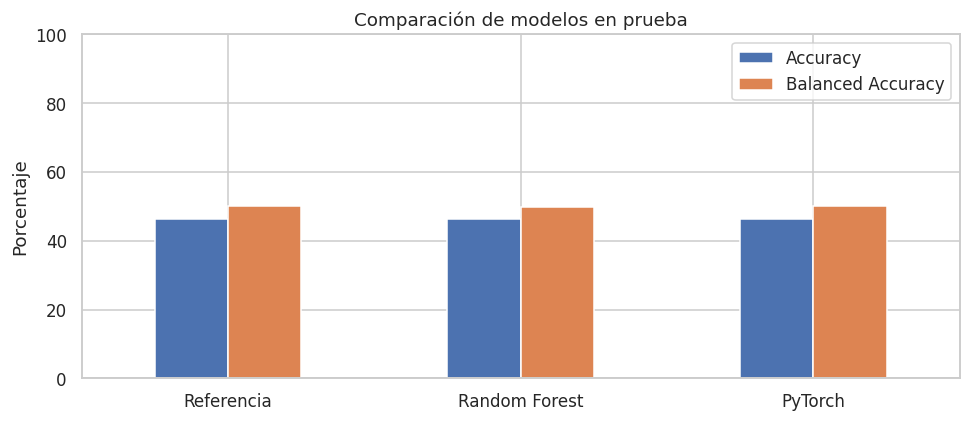

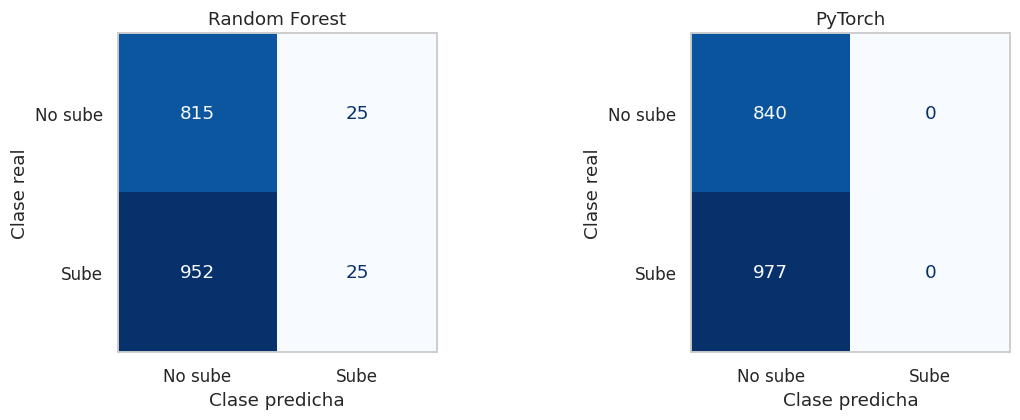

In [ ]:
# Contrasta exactitud total y detección equilibrada de ambas clases.
(resultados_test[["Accuracy", "Balanced Accuracy"]] * 100).plot.bar(
    figsize=(9, 4),
    rot=0,
)
plt.title("Comparación de modelos en prueba")
plt.ylabel("Porcentaje")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Cada matriz usa el mismo orden de clases: 0 y 1.
fig, ejes = plt.subplots(1, 2, figsize=(11, 4))

for eje, nombre in zip(ejes, ["Random Forest", "PyTorch"]):
    matriz = confusion_matrix(y_test, predicciones_test[nombre], labels=[0, 1])
    ConfusionMatrixDisplay(
        matriz,
        display_labels=["No sube", "Sube"],
    ).plot(ax=eje, cmap="Blues", colorbar=False)
    eje.set_title(nombre)
    eje.set_xlabel("Clase predicha")
    eje.set_ylabel("Clase real")
    eje.grid(False)

plt.tight_layout()
plt.show()


Fecha_informacion Sesion_predicha  Real  Random Forest  PyTorch
       2015-01-06      2015-01-07     1              0        0
       2015-01-07      2015-01-08     1              0        0
       2015-01-08      2015-01-09     0              0        0
       2015-01-09      2015-01-12     0              0        0
       2015-01-12      2015-01-13     0              0        0
       2015-01-13      2015-01-14     0              0        0
       2015-01-14      2015-01-15     0              0        0
       2015-01-15      2015-01-16     1              0        0
       2015-01-16      2015-01-20     1              0        0
       2015-01-20      2015-01-21     0              1        0
       2015-01-21      2015-01-22     1              0        0
       2015-01-22      2015-01-23     1              0        0


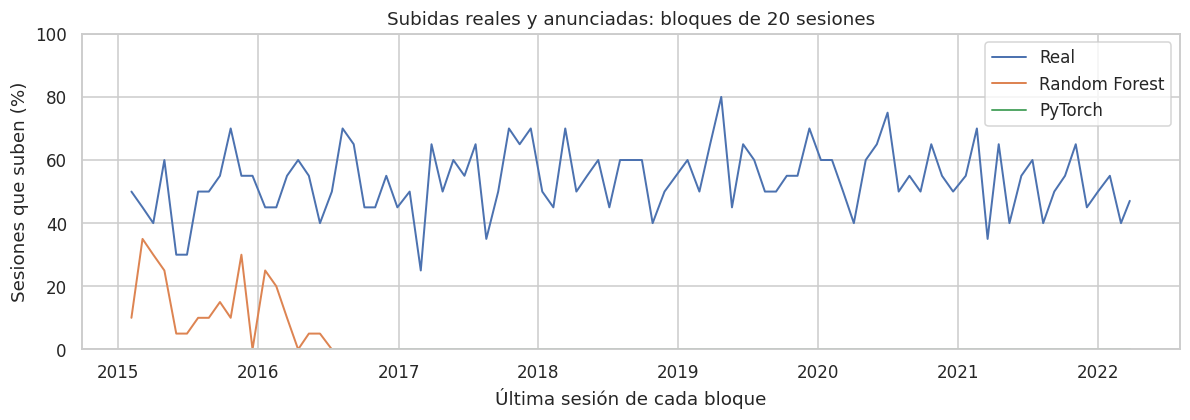

In [ ]:
# Mantiene separadas la fecha de información y la sesión que se predice.
comparacion = pd.DataFrame({
    "Fecha_informacion": datos_test["Fecha"].to_numpy(),
    "Sesion_predicha": datos_test["Fecha_Objetivo"].to_numpy(),
    "Real": y_test.to_numpy(),
    "Random Forest": predicciones_test["Random Forest"],
    "PyTorch": predicciones_test["PyTorch"],
})

print(comparacion.head(12).to_string(index=False))

# Agrupa 20 sesiones consecutivas solo para facilitar la visualización.
bloques = np.arange(len(comparacion)) // 20
tendencias = comparacion.groupby(bloques).agg({
    "Sesion_predicha": "max",
    "Real": "mean",
    "Random Forest": "mean",
    "PyTorch": "mean",
})

plt.figure(figsize=(11, 4))

for columna in ["Real", "Random Forest", "PyTorch"]:
    plt.plot(
        tendencias["Sesion_predicha"],
        tendencias[columna] * 100,
        label=columna,
        linewidth=1.3,
    )

plt.title("Subidas reales y anunciadas: bloques de 20 sesiones")
plt.xlabel("Última sesión de cada bloque")
plt.ylabel("Sesiones que suben (%)")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()


## 15. Interpretar las características del bosque
La importancia interna del Random Forest se obtiene de sus árboles. No equivale a causalidad, ni demuestra que una columna sea útil por sí sola. Los precios están relacionados entre sí, por lo que su importancia puede repartirse.

No atribuimos esta misma importancia a la red neuronal: son modelos diferentes.


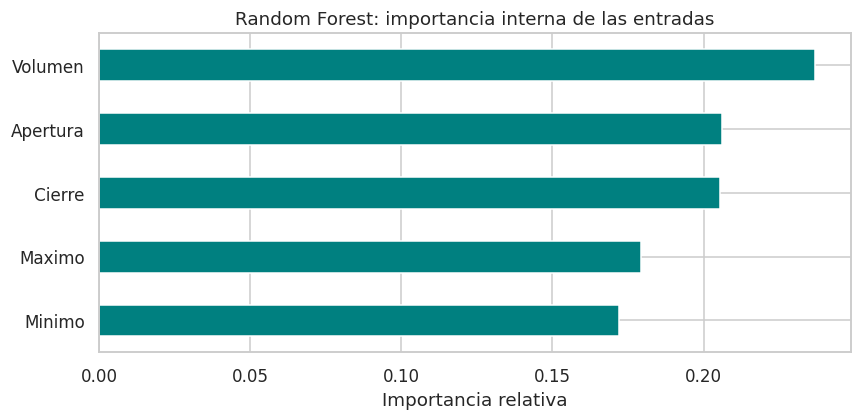

In [ ]:
# Ordena y muestra la importancia calculada durante el entrenamiento.
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=variables_independientes,
).sort_values()

importancias.plot.barh(color="teal", figsize=(8, 4))
plt.title("Random Forest: importancia interna de las entradas")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()


## 16. Conclusiones automáticas
La evaluación es parte de la solución: permite descartar expectativas que los datos no respaldan. No se fija una meta arbitraria de exactitud ni se presenta el aprendizaje profundo como una mejora garantizada.


In [ ]:
print(f"Se prepararon {len(df):,} sesiones y {len(df_ml):,} ejemplos etiquetados.")
print("Se conservaron cinco entradas originales; el retorno se usó solo para análisis.")
print(f"La red seleccionó la época {mejor_epoca} mediante validación, sin ajustar sobre la prueba.")

aciertos_referencia = int((predicciones_test["Referencia"] == y_test.to_numpy()).sum())

for nombre in ["Random Forest", "PyTorch"]:
    fila = resultados_test.loc[nombre]
    aciertos = int((predicciones_test[nombre] == y_test.to_numpy()).sum())
    diferencia = fila["Accuracy"] - resultados_test.loc["Referencia", "Accuracy"]
    print(f"\n{nombre}")
    print(f"  Accuracy de prueba: {fila['Accuracy']:.2%}")
    print(f"  Balanced Accuracy: {fila['Balanced Accuracy']:.2%}")
    print(f"  Recall de subidas: {fila['Recall']:.2%}")
    print(f"  Diferencia frente a referencia: {diferencia * 100:+.2f} puntos porcentuales")
    print(f"  Aciertos adicionales frente a referencia: {aciertos - aciertos_referencia:+d}")

    # Identifica si el modelo está respondiendo casi siempre lo mismo.
    porcentaje_subidas = np.mean(predicciones_test[nombre])
    print(f"  Sesiones anunciadas como subida: {porcentaje_subidas:.2%}")

    if len(np.unique(predicciones_test[nombre])) == 1:
        print("  Atención: predijo una sola clase en toda la prueba; no distinguió ambas tendencias.")

    if diferencia > 0:
        print("  Supera la referencia en exactitud en este período, sin demostrar estabilidad o rentabilidad.")
    else:
        print("  No supera la referencia en exactitud en este período.")

print("\nLa exactitud no mide rentabilidad. No se simularon inversiones, comisiones ni dividendos.")
print("El CSV termina en 2022; este experimento no ofrece una predicción del mercado actual.")
print("El período final ya se examinó antes: hace falta una evaluación independiente para confirmar resultados.")


Se prepararon 9,083 sesiones y 9,082 ejemplos etiquetados.
Se conservaron cinco entradas originales; el retorno se usó solo para análisis.
La red seleccionó la época 2 mediante validación, sin ajustar sobre la prueba.

Random Forest
  Accuracy de prueba: 46.23%
  Balanced Accuracy: 49.79%
  Recall de subidas: 2.56%
  Diferencia frente a referencia: +0.00 puntos porcentuales
  Aciertos adicionales frente a referencia: +0
  Sesiones anunciadas como subida: 2.75%
  No supera la referencia en exactitud en este período.

PyTorch
  Accuracy de prueba: 46.23%
  Balanced Accuracy: 50.00%
  Recall de subidas: 0.00%
  Diferencia frente a referencia: +0.00 puntos porcentuales
  Aciertos adicionales frente a referencia: +0
  Sesiones anunciadas como subida: 0.00%
  Atención: predijo una sola clase en toda la prueba; no distinguió ambas tendencias.
  No supera la referencia en exactitud en este período.

La exactitud no mide rentabilidad. No se simularon inversiones, comisiones ni dividendos.
El CS

## 17. Evidencia de avance frente al enunciado

| Solicitud | Estado de este notebook | Evidencia o siguiente paso |
|---|---|---|
| CSV, Pandas y NumPy | Implementado | Lectura, comprobaciones, transformación, estadísticas, vector y matriz |
| Clasificación con Scikit-learn | Implementado | Random Forest y referencia |
| Uso de PyTorch | Implementado | Tensores, red densa, Autograd, Adam y validación |
| Preprocesamiento y validación | Implementado a nivel inicial | Orden temporal, dos separaciones, escalador ajustado solo con train, elección de época en validación |
| Entrenamiento y evaluación | Implementado | Métricas de validación/prueba y matrices de confusión |
| Matplotlib y Seaborn | Implementado | Líneas, histograma, dispersión y comparaciones |
| Comparación de tendencias | Implementado | Porcentajes reales y predichos en bloques temporales |
| NLP, SciPy y NLTK | Pendiente | Reunir reportes financieros en texto y aplicar extracción/tokenización |
| TensorFlow/Keras y red temporal | Pendiente | Construir secuencias y evaluar una red temporal con división cronológica |
| Informe técnico final | Pendiente | Usar los procedimientos y resultados como base, sin afirmar que el caso está terminado |

**No se añaden herramientas solo para nombrarlas.** No aplicamos clustering porque nuestra pregunta dispone de una respuesta histórica; es aprendizaje supervisado. Tampoco se fabrican nulos ni reportes para simular cumplimiento.

## 18. Preguntas para la exposición

| Pregunta | Respuesta breve |
|---|---|
| ¿Qué dificultad atiende esta solución? | Organiza la preparación y evaluación para que un analista pueda revisar datos y comparar modelos con evidencia. |
| ¿Por qué PyTorch? | Permite aplicar la red y el ciclo de aprendizaje vistos en sesión 02, y comprobar otra alternativa. |
| ¿Qué es un tensor aquí? | La tabla de cinco entradas convertida a una estructura numérica de PyTorch. |
| ¿Qué hace backward? | Calcula los gradientes del error respecto a los pesos. |
| ¿Qué hace step? | Actualiza los pesos usando esos gradientes. |
| ¿Qué diferencia hay entre validación y prueba? | La validación selecciona la época; la prueba compara el modelo ya fijado. |
| ¿Por qué estandarizar? | Para que las diferencias de escala entre precios y volumen no dificulten tanto el entrenamiento de la red. |
| ¿Se crearon otros indicadores para X? | No: son las mismas cinco columnas, representadas en otra escala para la red. |
| ¿Una red siempre supera al bosque? | No. Lo decide la evaluación, y ambos pueden fallar. |
| ¿Por qué mirar Balanced Accuracy? | Una exactitud aparentemente aceptable puede ocultar que se detecta casi una sola clase. |
| ¿Se puede utilizar ya para invertir? | Este experimento no demuestra rentabilidad ni estabilidad y necesita evaluación independiente. |

**Limitaciones:** muestra histórica de una sola acción, posibles cambios del mercado entre épocas, ajustes del proveedor que deben documentarse para una simulación financiera rigurosa, ausencia de noticias, un único esquema de validación y prueba y ninguna evaluación del ahorro de tiempo empresarial. Las cinco entradas de la sesión actual no resumen explícitamente varias sesiones pasadas.

**Próximo avance:** incorporar reportes reales de Microsoft para el bloque de NLP y después una red de series temporales. La mejora académica de este notebook es un procedimiento más completo y comprensible; no se confunde con una mejora predictiva garantizada.

## Referencias técnicas
- PyTorch, aprendizaje básico: https://docs.pytorch.org/tutorials/beginner/basics/intro.html
- PyTorch, ciclo de optimización: https://github.com/pytorch/tutorials/blob/main/beginner_source/basics/optimization_tutorial.py
- Scikit-learn, estandarización: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- Scikit-learn, división temporal: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html
- Material entregado: Sesión 01, Sesión 02 y TrabajoFinalMachineLearning.txt.
